## Imports :

In [1]:
import joblib

import scipy as sp
from scipy.stats import skew, boxcox, mode
from scipy.spatial import distance
import cvxpy as cp

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import missingno as msno
from sklearn.impute import SimpleImputer 

from sklearn.linear_model import LinearRegression, SGDRegressor, Ridge, ElasticNet, Lasso, RidgeCV, LassoCV, ElasticNetCV, LogisticRegression, SGDClassifier, LogisticRegressionCV, RidgeClassifier, RidgeClassifierCV
from sklearn.preprocessing import PolynomialFeatures, SplineTransformer, PowerTransformer, FunctionTransformer, QuantileTransformer, LabelEncoder, OneHotEncoder, MinMaxScaler, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn import metrics
from sklearn.utils.extmath import weighted_mode
from sklearn.model_selection import train_test_split, KFold, LeaveOneOut, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.datasets import load_breast_cancer, make_classification, make_blobs, make_circles, load_iris, make_regression
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.svm import LinearSVC, SVC, NuSVC
from sklearn.neighbors import KDTree, BallTree, NearestNeighbors

from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.basemap import Basemap
from scipy.ndimage import gaussian_filter1d
import seaborn as sns
from mlxtend.plotting import plot_decision_regions

from mlxtend.evaluate import bias_variance_decomp

## Load data :

In [2]:
dfN = pd.read_csv('../data/train_set_eN.csv')
dfS = pd.read_csv('../data/train_set_eS.csv')

In [3]:
x_trainN, y_trainN = np.array(dfN.iloc[:, :-1]), np.array(dfN.iloc[:, [-1]])
x_trainN.shape, y_trainN.shape

((28932, 31), (28932, 1))

In [4]:
x_trainS, y_trainS = np.array(dfS.iloc[:, :-1]), np.array(dfS.iloc[:, [-1]])
x_trainS.shape, y_trainS.shape

((28932, 31), (28932, 1))

In [5]:
df_vallN = pd.read_csv("../data/vall_set_eN.csv")
df_vallS = pd.read_csv("../data/vall_set_eS.csv")

In [6]:
x_vallN, y_vallN = np.array(df_vallN.iloc[:, :-1]), np.array(df_vallN.iloc[:, [-1]])
x_vallN.shape, y_vallN.shape

((7234, 31), (7234, 1))

In [7]:
x_vallS, y_vallS = np.array(df_vallS.iloc[:, :-1]), np.array(df_vallS.iloc[:, [-1]])
x_vallS.shape, y_vallS.shape

((7234, 31), (7234, 1))

In [8]:
df_testN = pd.read_csv("../data/test_set_eN.csv")
df_testS = pd.read_csv("../data/test_set_eS.csv")

In [9]:
x_testN, y_testN = np.array(df_testN.iloc[:, :-1]), np.array(df_testN.iloc[:, [-1]])
x_testN.shape, y_testN.shape

((9043, 31), (9043, 1))

In [10]:
x_testS, y_testS = np.array(df_testS.iloc[:, :-1]), np.array(df_testS.iloc[:, [-1]])
x_testS.shape, y_testS.shape

((9043, 31), (9043, 1))

In [11]:
y_trainS = np.where(y_trainS == 0, -1.0, 1.0)
y_testS = np.where(y_testS == 0, -1.0, 1.0)
y_vallS = np.where(y_vallS == 0, -1.0, 1.0)

In [12]:
x_trainS.shape, x_vallS.shape

((28932, 31), (7234, 31))

In [13]:
x_train_complet = np.vstack((x_trainS, x_vallS))

In [14]:
y_train_complet = np.vstack((y_trainS, y_vallS))

## load models :

In [15]:
model_logistic = joblib.load('../models/best_logistic_model')

In [16]:
model_MLPnetwork = joblib.load('../models/best_MLPnetwork')

In [17]:
model_KNN = joblib.load('../models/best_model_KNN')

In [18]:
model_NuSVC = joblib.load('../models/best_model_NuSVC')

In [19]:
model_svc_rbf = joblib.load('../models/best_model_svc_rbf')

In [15]:
decision_tree = joblib.load('../models/decision_tree')

## Test :

### refit model :

In [20]:
model_KNN.fit(x_train_complet, y_train_complet.ravel())

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",15
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",40
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'manhattan'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [21]:
model_KNN.score(x_train_complet, y_train_complet)

1.0

In [22]:
model_logistic.fit(x_train_complet, y_train_complet.ravel())

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",101
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term

In [23]:
model_logistic.score(x_train_complet, y_train_complet)

0.8248354808383564

In [24]:
model_MLPnetwork.fit(x_train_complet, y_train_complet.ravel())

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(90,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.01
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",1000
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",100


In [25]:
model_MLPnetwork.score(x_train_complet, y_train_complet)

0.8830116684178511

In [26]:
model_NuSVC.fit(x_train_complet, y_train_complet.ravel())

,"nu nu: float, default=0.5An upper bound on the fraction of margin errors (see :ref:`User Guide`) and a lower bound of the fraction of support vectors.Should be in the interval (0, 1].",0.2
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'auto'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: {dict, 'balanced'}, default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one. The ""balanced"" mode uses the values of y to automaticallyadjust weights inversely proportional to class frequencies as``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [27]:
model_NuSVC.score(x_train_complet, y_train_complet)

0.8829840181385832

In [28]:
model_svc_rbf.fit(x_train_complet, y_train_complet.ravel())

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",np.float64(0....7214690901213)
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'auto'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [29]:
model_svc_rbf.score(x_train_complet, y_train_complet)

0.9679809766078638

In [16]:
decision_tree.fit(x_train_complet, y_train_complet.ravel())

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",100
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curren

In [17]:
decision_tree.score(x_train_complet, y_train_complet)

1.0

### accuracy :

In [30]:
metrics.accuracy_score(y_testS, model_KNN.predict(x_testS))

0.8900807254229791

In [31]:
metrics.accuracy_score(y_testS, model_logistic.predict(x_testS))

0.8331305982527922

In [32]:
metrics.accuracy_score(y_testS, model_MLPnetwork.predict(x_testS))

0.8831140108371116

In [33]:
metrics.accuracy_score(y_testS, model_NuSVC.predict(x_testS))

0.8831140108371116

In [34]:
metrics.accuracy_score(y_testS, model_svc_rbf.predict(x_testS))

0.8867632422868517

In [18]:
metrics.accuracy_score(y_testS, decision_tree.predict(x_testS))

0.8821187658962734

### TP, TN, FP, FN :

In [35]:
tn_knn, fp_knn, fn_knn, tp_knn = metrics.confusion_matrix(y_train_complet, model_KNN.predict(x_train_complet)).ravel().tolist()
tn_knn, fp_knn, fn_knn, tp_knn

(31935, 0, 0, 4231)

In [36]:
tn_knn_test, fp_knn_test, fn_knn_test, tp_knn_test = metrics.confusion_matrix(y_testS, model_KNN.predict(x_testS)).ravel().tolist()
tn_knn_test, fp_knn_test, fn_knn_test, tp_knn_test

(7718, 267, 727, 331)

In [37]:
tn_mlp, fp_mlp, fn_mlp, tp_mlp = metrics.confusion_matrix(y_train_complet, model_MLPnetwork.predict(x_train_complet)).ravel().tolist()
tn_mlp, fp_mlp, fn_mlp, tp_mlp

(31934, 1, 4230, 1)

In [38]:
tn_mlp_test, fp_mlp_test, fn_mlp_test, tp_mlp_test = metrics.confusion_matrix(y_testS, model_MLPnetwork.predict(x_testS)).ravel().tolist()
tn_mlp_test, fp_mlp_test, fn_mlp_test, tp_mlp_test

(7984, 1, 1056, 2)

In [39]:
tn_logistic, fp_logistic, fn_logistic, tp_logistic = metrics.confusion_matrix(y_train_complet, model_logistic.predict(x_train_complet)).ravel().tolist()
tn_logistic, fp_logistic, fn_logistic, tp_logistic

(26192, 5743, 592, 3639)

In [40]:
tn_logistic_test, fp_logistic_test, fn_logistic_test, tp_logistic_test = metrics.confusion_matrix(y_testS, model_logistic.predict(x_testS)).ravel().tolist()
tn_logistic_test, fp_logistic_test, fn_logistic_test, tp_logistic_test

(6629, 1356, 153, 905)

In [41]:
tn_NuSVC, fp_NuSVC, fn_NuSVC, tp_NuSVC = metrics.confusion_matrix(y_train_complet, model_NuSVC.predict(x_train_complet)).ravel().tolist()
tn_NuSVC, fp_NuSVC, fn_NuSVC, tp_NuSVC

(31931, 4, 4228, 3)

In [42]:
tn_NuSVC_test, fp_NuSVC_test, fn_NuSVC_test, tp_NuSVC_test = metrics.confusion_matrix(y_testS, model_NuSVC.predict(x_testS)).ravel().tolist()
tn_NuSVC_test, fp_NuSVC_test, fn_NuSVC_test, tp_NuSVC_test

(7984, 1, 1056, 2)

In [43]:
tn_rbf, fp_rbf, fn_rbf, tp_rbf = metrics.confusion_matrix(y_train_complet, model_svc_rbf.predict(x_train_complet)).ravel().tolist()
tn_rbf, fp_rbf, fn_rbf, tp_rbf

(31331, 604, 554, 3677)

In [44]:
tn_rbf_test, fp_rbf_test, fn_rbf_test, tp_rbf_test = metrics.confusion_matrix(y_testS, model_svc_rbf.predict(x_testS)).ravel().tolist()
tn_rbf_test, fp_rbf_test, fn_rbf_test, tp_rbf_test

(7763, 222, 802, 256)

In [19]:
tn_tree, fp_tree, fn_tree, tp_tree = metrics.confusion_matrix(y_train_complet, decision_tree.predict(x_train_complet)).ravel().tolist()
tn_tree, fp_tree, fn_tree, tp_tree

(31935, 0, 0, 4231)

In [20]:
tn_tree_test, fp_tree_test, fn_tree_test, tp_tree_test = metrics.confusion_matrix(y_testS, decision_tree.predict(x_testS)).ravel().tolist()
tn_tree_test, fp_tree_test, fn_tree_test, tp_tree_test

(7499, 486, 580, 478)

### ROC :

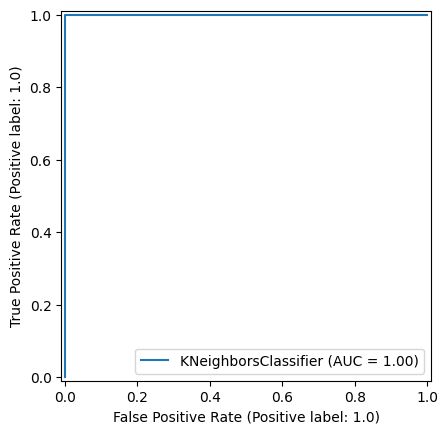

In [45]:
metrics.RocCurveDisplay.from_estimator(estimator=model_KNN, X=x_train_complet, y=y_train_complet)

C:\Users\Ertebatat-Sahar\anaconda3\envs\python_Ai\Lib\site-packages\sklearn\utils\_plotting.py:440: FutureWarning: y_pred was deprecated in 1.7 and will be removed in 1.9. Please use `y_score` instead.
  warnings.warn(


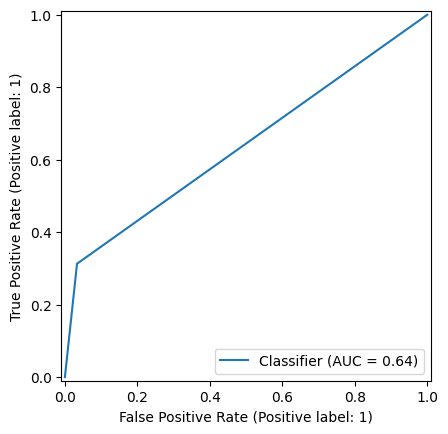

In [46]:
metrics.RocCurveDisplay.from_predictions(y_true=y_testS, y_pred=model_KNN.predict(x_testS))

C:\Users\Ertebatat-Sahar\anaconda3\envs\python_Ai\Lib\site-packages\sklearn\utils\_plotting.py:440: FutureWarning: y_pred was deprecated in 1.7 and will be removed in 1.9. Please use `y_score` instead.
  warnings.warn(


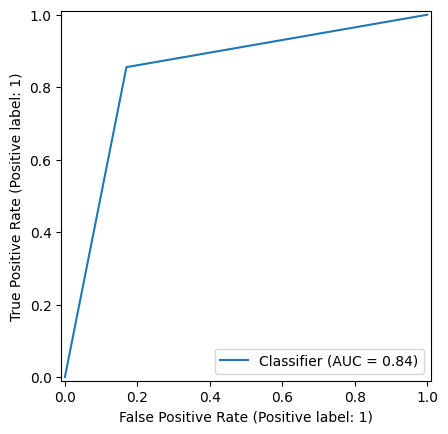

In [47]:
metrics.RocCurveDisplay.from_predictions(y_true=y_testS, y_pred=model_logistic.predict(x_testS))

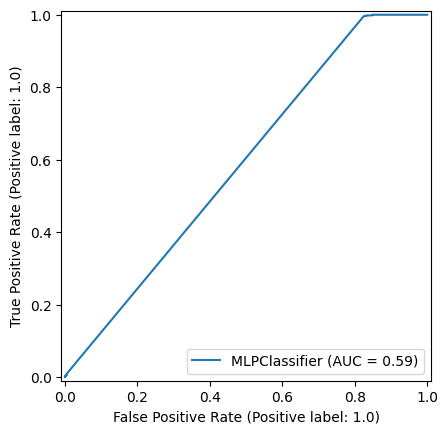

In [48]:
metrics.RocCurveDisplay.from_estimator(estimator=model_MLPnetwork, X=x_testS, y=y_testS)

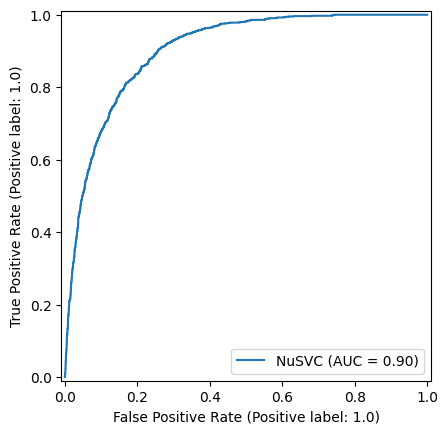

In [49]:
metrics.RocCurveDisplay.from_estimator(estimator=model_NuSVC, X=x_testS, y=y_testS)

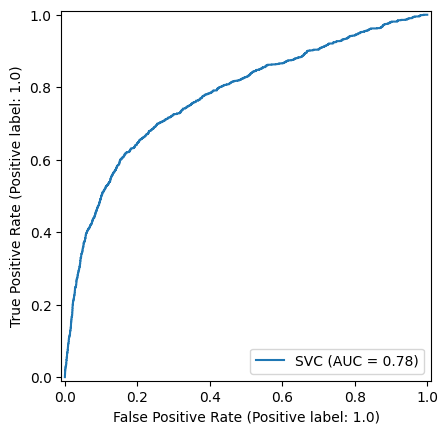

In [50]:
metrics.RocCurveDisplay.from_estimator(estimator=model_svc_rbf, X=x_testS, y=y_testS)

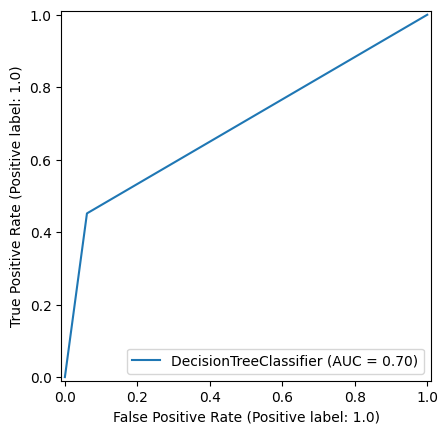

In [21]:
metrics.RocCurveDisplay.from_estimator(estimator=decision_tree, X=x_testS, y=y_testS)

### Recall and sensevity :

In [51]:
metrics.recall_score(y_testS, model_KNN.predict(x_testS))

0.31285444234404536

In [52]:
metrics.recall_score(y_testS, model_logistic.predict(x_testS))

0.8553875236294896

In [53]:
metrics.recall_score(y_testS, model_MLPnetwork.predict(x_testS))

0.001890359168241966

In [54]:
metrics.recall_score(y_testS, model_NuSVC.predict(x_testS))

0.001890359168241966

In [55]:
metrics.recall_score(y_testS, model_svc_rbf.predict(x_testS))

0.24196597353497165

In [22]:
metrics.recall_score(y_testS, decision_tree.predict(x_testS))

0.45179584120982985

### precision :

In [56]:
metrics.precision_score(y_testS, model_KNN.predict(x_testS))

0.5535117056856187

In [57]:
metrics.precision_score(y_testS, model_logistic.predict(x_testS))

0.40026536930561696

In [58]:
metrics.precision_score(y_testS, model_MLPnetwork.predict(x_testS))

0.6666666666666666

In [59]:
metrics.precision_score(y_testS, model_NuSVC.predict(x_testS))

0.6666666666666666

In [60]:
metrics.precision_score(y_testS, model_svc_rbf.predict(x_testS))

0.5355648535564853

In [23]:
metrics.precision_score(y_testS, decision_tree.predict(x_testS))

0.495850622406639

### specificity :

In [61]:
tn_knn / (tn_knn + fp_knn)

1.0

In [62]:
tn_knn_test / (tn_knn_test + fp_knn_test)

0.9665623043206011

In [63]:
tn_logistic / (tn_logistic + fp_logistic)

0.820165962110537

In [64]:
tn_logistic_test / (tn_logistic_test + fp_logistic_test)

0.830181590482154

In [65]:
tn_mlp / (tn_mlp + fp_mlp)

0.9999686863942383

In [66]:
tn_mlp_test / (tn_mlp_test + fp_mlp_test)

0.9998747651847214

In [67]:
tn_NuSVC / (tn_NuSVC + fp_NuSVC)

0.9998747455769532

In [68]:
tn_NuSVC_test / (tn_NuSVC_test + fp_NuSVC_test)

0.9998747651847214

In [69]:
tn_rbf / (tn_rbf + fp_rbf)

0.9810865821199312

In [70]:
tn_rbf_test / (tn_rbf_test + fp_rbf_test)

0.9721978710081403

In [24]:
tn_tree / (tn_tree + fp_tree)

1.0

In [25]:
tn_tree_test / (tn_tree_test + fp_tree_test)

0.9391358797745774

### F1_score :

In [71]:
metrics.f1_score(y_testS, model_KNN.predict(x_testS))

0.3997584541062802

In [72]:
metrics.f1_score(y_testS, model_logistic.predict(x_testS))

0.5453449834287436

In [73]:
metrics.f1_score(y_testS, model_MLPnetwork.predict(x_testS))

0.003770028275212064

In [74]:
metrics.f1_score(y_testS, model_NuSVC.predict(x_testS))

0.003770028275212064

In [75]:
metrics.f1_score(y_testS, model_svc_rbf.predict(x_testS))

0.3333333333333333

In [26]:
metrics.f1_score(y_testS, decision_tree.predict(x_testS))

0.47279920870425324